# Tutorial: Hop-Skip-Jump algorithm x PyPSA

In [1]:
import yaml
import pypsa

from mga4all.examples import create_pypsa_network

import pandas as pd

## 1. Load example PyPSA model

In [2]:
# Load example PyPSA model that the config refers to
n = create_pypsa_network()

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


In [3]:
# Set the desired solver options
pypsa.options.params.optimize.solver_name = "gurobi"
pypsa.options.params.optimize.solver_options = {
    'Method': 2,  # Use the barrier algorithm
    'Crossover': 0,
}

In [4]:
# Find cost-optimal solution
n.optimize(log_to_console=False);

/tmp/ipykernel_93575/2238090962.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(log_to_console=False);
Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False
INFO:linopy.io: Writing time: 0.33s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2027-09-07


INFO:gurobipy:Academic license - for non-commercial use only - expires 2027-09-07


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Linux Mint 22")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i7-10610U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 688 rows, 296 columns and 1324 nonzeros
INFO:gurobipy:Model fingerprint: 0xd41ae2e6
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 5e+00]
INFO:gurobipy:  Objective range  [4e+02, 2e+03]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 1e+03]
INFO:gurobipy:Presolve removed 124 rows and 332 columns
INFO:gurobipy:Presolve time: 0.02s
INFO:gurobipy:Presolved: 172 rows, 356 columns, 1572 nonzeros


## 2. Generate alternative solutions with Hop-Skip-Jump MGA

### 2.1 Load and check MGA configuration

In [5]:
from mga4all.validate import HopSkipJumpConfig

# Load configuration file
with open("../../configs/test_config_hop_skip_jump.yaml") as yf:
    test_config = HopSkipJumpConfig.model_validate(yaml.safe_load(yf))

In [6]:
# Check that it reflects the desired setup
test_config

HopSkipJumpConfig(config_name='hop-skip-jump', model_interface='pypsa', alternatives=5, cost_slack=0.2, spatially_explicit=False, diversification_coefficient=1, diversified_technologies=['wind', 'solar', 'gas', 'battery'])

### 2.2 Import algorithm and run

In [7]:
from mga4all.mga_hop_skip_jump import hop_skip_jump_algorithm

In [8]:
# Define a 'noise threshold' to avoid penalising small capacity deployment
noise_threshold = int(n.statistics.optimal_capacity().min())
noise_threshold 

44

In [ ]:
mga_spatial_alternatives, mga_alternatives, mga_weights = hop_skip_jump_algorithm(
    test_config, 
    n, 
    noise_threshold,
    export_nc=False # define str path to export full NetCDF files of each alternative
    )

Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False


Technologies [] not found in the model


INFO:linopy.io: Writing time: 0.23s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Linux Mint 22")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i7-10610U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 689 rows, 296 columns and 1332 nonzeros
INFO:gurobipy:Model fingerprint: 0xb9c51cc6
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 2e+03]
INFO:gurobipy:  Objective range  [1e+00, 5e+00]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 7e+05]
INFO:gurobipy:Presolve removed 124 rows and 334 columns
INFO:gurobipy:Presolve time: 0.01s
INFO:gurobipy:Presolved: 172 rows, 355 columns, 1578 nonzeros


### 2.3 Inspect the alternatives

<Axes: >

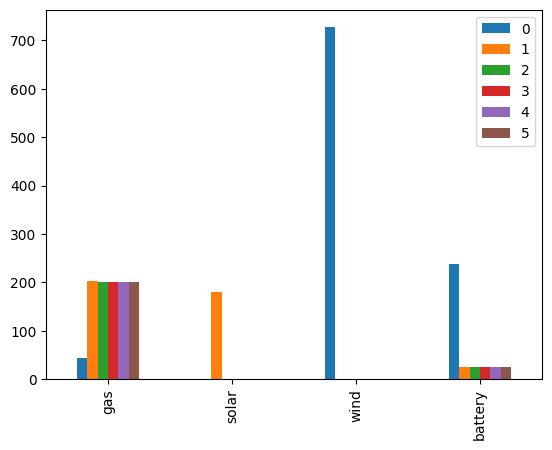

In [10]:
mga_alternatives.plot.bar()

<Axes: >

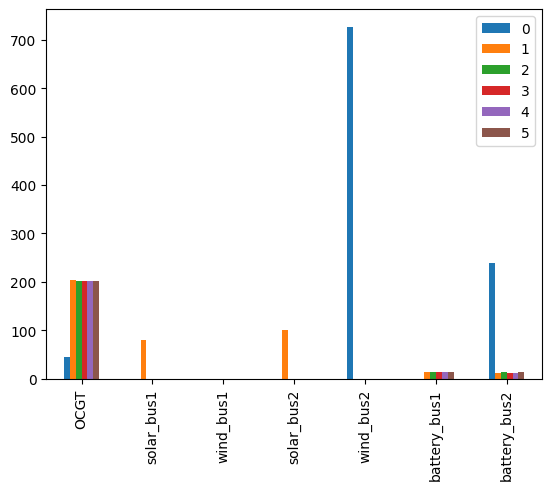

In [11]:
mga_spatial_alternatives.plot.bar()

In [12]:
mga_weights

,0,1,2,3,4,5
gas,1.0,2.0,3.0,4.0,5.0,5.0
solar,0.0,1.0,1.0,1.0,1.0,1.0
wind,1.0,1.0,1.0,1.0,1.0,1.0
battery,1.0,1.0,1.0,1.0,1.0,1.0


In [13]:
from mga4all.exploration_metrics import exploration_metrics_progression
from mga4all.model_interface_pypsa import extract_capacity_bounds

# Let's first extract the feasibility bounds of the model, needed for the Shannon index.
bounds_spatial, bounds_aggregate = extract_capacity_bounds(n, test_config)

# Then, let's generate diversity metrics with the pre-built functionality
metrics = exploration_metrics_progression(mga_alternatives, lb=bounds_aggregate['lb'], ub=bounds_aggregate['ub'])

Technologies [] not found in the model


<Axes: >

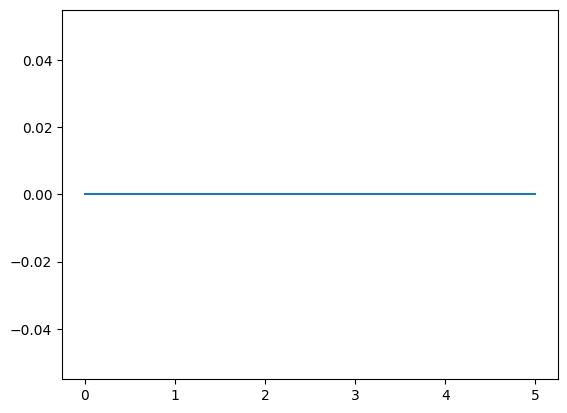

In [14]:
metrics['Shannon'].plot()

<Axes: >

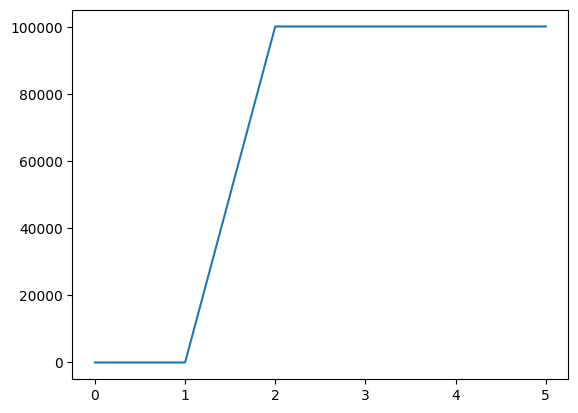

In [15]:
metrics['VESA'].plot()